<a href="https://colab.research.google.com/github/marciapaulasv-coder/TechChalenge/blob/main/03_modelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

In [2]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (25519, 47)
X_test: (10938, 47)
y_train: (25519,)
y_test: (10938,)


**1) Regressão Logistica**

In [7]:
from sklearn.linear_model import LogisticRegression

# Criação do modelo de Regressão Logística
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)

# Treinamento do modelo com os dados de treino
modelo_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [9]:
# Previsão na base de teste

y_pred_lr = modelo_lr.predict(X_test)

In [10]:
# Avaliação inicial da Regressão Logística

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9651
           1       0.00      0.00      0.00      1287

    accuracy                           0.88     10938
   macro avg       0.44      0.50      0.47     10938
weighted avg       0.78      0.88      0.83     10938



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Conclusão:** Apesar da acurácia de aproximadamente 88%, o modelo não conseguiu identificar nenhum cliente da classe 1 (mau pagador), apresentando recall e F1-score iguais a zero para essa classe. O resultado evidencia o impacto do desbalanceamento do TARGET e demonstra que a acurácia, isoladamente, não é adequada para avaliar o desempenho do modelo neste problema.

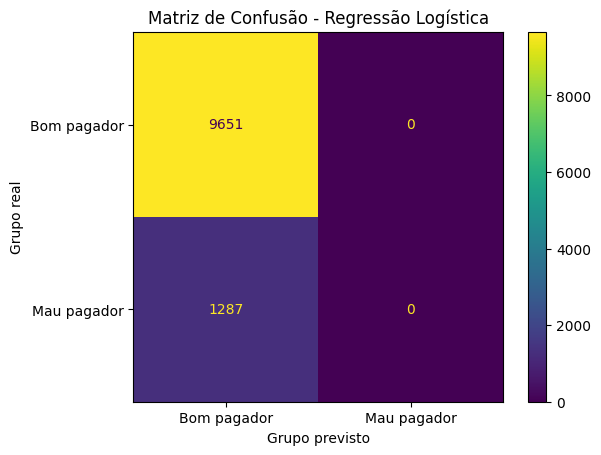

In [17]:
# Matriz de confusão da Regressão Logística

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

matriz_lr = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(confusion_matrix=matriz_lr, display_labels=['Bom pagador', 'Mau pagador']).plot()

plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Grupo previsto')
plt.ylabel('Grupo real')
plt.show()

**Conclusão:** A matriz de confusão mostra que o modelo classificou todos os clientes como bons pagadores. Embora tenha identificado corretamente os 9.651 bons pagadores, os 1.287 maus pagadores também foram classificados como bons, resultando em recall igual a zero para a classe minoritária. Esse resultado evidencia o impacto do desbalanceamento das classes e reforça a necessidade de utilizar estratégias para melhorar a identificação dos maus pagadores.

In [12]:
# Regressão Logística com tratamento do desbalanceamento

modelo_lr_balanceado = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Treinamento do modelo
modelo_lr_balanceado.fit(X_train, y_train)

# Previsão na base de teste
y_pred_lr_balanceado = modelo_lr_balanceado.predict(X_test)

In [13]:
# Avaliação da Regressão Logística com balanceamento

print(classification_report(y_test, y_pred_lr_balanceado))

              precision    recall  f1-score   support

           0       0.90      0.59      0.71      9651
           1       0.14      0.48      0.21      1287

    accuracy                           0.58     10938
   macro avg       0.52      0.54      0.46     10938
weighted avg       0.81      0.58      0.65     10938



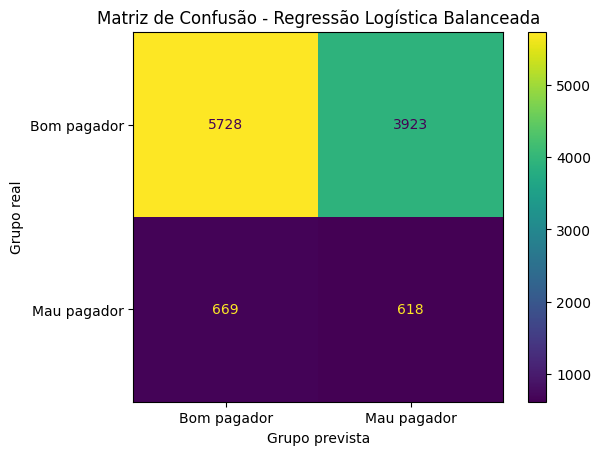

In [18]:
# Matriz de confusão da Regressão Logística com balanceamento

matriz_lr_balanceado = confusion_matrix(y_test, y_pred_lr_balanceado)

ConfusionMatrixDisplay(confusion_matrix=matriz_lr_balanceado, display_labels=['Bom pagador', 'Mau pagador']).plot()

plt.title('Matriz de Confusão - Regressão Logística Balanceada')
plt.xlabel('Grupo prevista')
plt.ylabel('Grupo real')
plt.show()


**Conclusão:** Com o uso de class_weight='balanced', o modelo passou a identificar 618 dos 1.287 maus pagadores, elevando o recall da classe 1 de 0% para 48%. No entanto, também classificou incorretamente 3.923 bons pagadores como maus, resultando em baixa precisão para a classe 1 (14%). O resultado demonstra que o tratamento do desbalanceamento aumentou a capacidade de identificar maus pagadores, mas também elevou a ocorrência de falsos positivos.

**2) Random Forest**

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Criação do modelo Random Forest com tratamento do desbalanceamento
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Treinamento do modelo com os dados de treino
modelo_rf.fit(X_train, y_train)

# Previsão na base de teste
y_pred_rf = modelo_rf.predict(X_test)

In [20]:
# Avaliação do modelo Random Forest

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91      9651
           1       0.36      0.51      0.43      1287

    accuracy                           0.84     10938
   macro avg       0.65      0.70      0.67     10938
weighted avg       0.86      0.84      0.85     10938



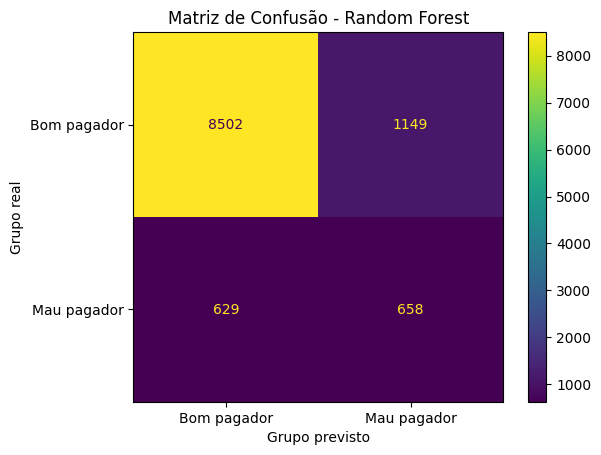

In [21]:
# Matriz de confusão da Random Forest

matriz_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=matriz_rf, display_labels=['Bom pagador', 'Mau pagador']).plot()

plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Grupo previsto')
plt.ylabel('Grupo real')
plt.show()

**Conclusão:** A Random Forest identificou corretamente 658 dos 1.287 maus pagadores, correspondendo a um recall de 51% para a classe 1. Além disso, 1.149 bons pagadores foram classificados incorretamente como maus. Em comparação com a Regressão Logística balanceada, a Random Forest apresentou melhor equilíbrio entre a identificação dos maus pagadores e a redução de falsos positivos, refletido também no aumento da precisão e do F1-score da classe minoritária.

In [22]:
# Probabilidades previstas pelos modelos para a classe 1 (mau pagador)

y_prob_lr = modelo_lr_balanceado.predict_proba(X_test)[:, 1]
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [25]:
# Cálculo das métricas ROC-AUC e Average Precision (AP)

from sklearn.metrics import roc_auc_score, average_precision_score

roc_lr = roc_auc_score(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)

roc_rf = roc_auc_score(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

print(f'Regressão Logística - ROC-AUC: {roc_lr:.3f} | AP: {ap_lr:.3f}')
print(f'Random Forest       - ROC-AUC: {roc_rf:.3f} | AP: {ap_rf:.3f}')

Regressão Logística - ROC-AUC: 0.553 | AP: 0.144
Random Forest       - ROC-AUC: 0.784 | AP: 0.385


**Conclusão: **A Random Forest apresentou desempenho superior à Regressão Logística na capacidade de diferenciar bons e maus pagadores, alcançando ROC-AUC de 0,784 contra 0,553. A diferença também foi observada na Average Precision (AP), com valores de 0,385 e 0,144, respectivamente. Considerando o desbalanceamento das classes, esses resultados reforçam o melhor desempenho da Random Forest na identificação da classe minoritária.